# scipy

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## 微分方程

求解带初值的 常微分方程组
$$
\begin{cases}
\frac{dy}{dt} = f(y, t) \\
y(t_0) = y_0
\end{cases}
$$
- `t` 一维自变量（时间）
- `y` N维向量（状态）。
- 给定初值，近似找到满足方程的函数 $y(t)$。

In [2]:
from scipy.integrate import solve_ivp

In [4]:
# 定义 dy/dt = ..
def my_func(t, y):
    return -2 * y + np.sin(t)
y0 = [1.0]
t_span = [0,10]
t_eval = np.linspace(0, 10, 100)
sol = solve_ivp(my_func, t_span, y0, t_eval=t_eval)

In [5]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-01 ...  9.899e+00  1.000e+01]
        y: [[ 1.000e+00  8.218e-01 ... -4.818e-03 -4.987e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 134
     njev: 0
      nlu: 0

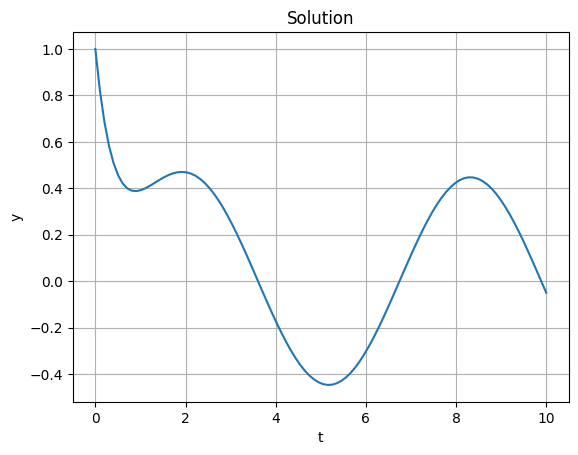

In [8]:
plt.plot(sol.t, sol.y[0])
plt.xlabel('t')
plt.ylabel('y')
plt.title('Solution')
plt.grid(True)
plt.show()

## 稀疏矩阵

In [ ]:
from scipy import sparse

# 1️⃣ 记录非零元素的行索引
row = np.array([0, 2, 2, 4])  # 3 在第0行，4 在第2行，5 在第2行，6 在第4行

# 2️⃣ 记录非零元素的列索引
col = np.array([2, 0, 3, 2])  # 3 在第2列，4 在第0列，5 在第3列，6 在第2列

# 3️⃣ 记录非零元素的值
data = np.array([3, 4, 5, 6])  # 这些索引位置对应的值

# 4️⃣ 生成 5x5 的稀疏矩阵
matrix = sparse.coo_matrix((data, (row, col)), shape=(5, 5))

# 打印矩阵
print(matrix.toarray())  # 转换回普通的二维数组看下
print(matrix.row)
print(matrix.col)
print(matrix.data)


[[0 0 3 0 0]
 [0 0 0 0 0]
 [4 0 0 5 0]
 [0 0 0 0 0]
 [0 0 6 0 0]]
[0 2 2 4]
[2 0 3 2]
[3 4 5 6]


scipy.sparse._coo.coo_array用坐标格式表示稀疏数组。通过三个数组：值，行，列。存储

In [2]:
import numpy as np
from scipy.sparse import coo_array

In [4]:
# 定义非零数据及其对应的坐标
row  = np.array([0, 3, 1, 0])
col  = np.array([0, 3, 1, 2])
data = np.array([4, 5, 7, 9])

In [14]:
coo_arr= coo_array((data, (row, col)))


In [20]:
coo_arr.coords

(array([0, 3, 1, 0]), array([0, 3, 1, 2]))

In [18]:
# 转换为 coo_matrix
coo_mtx = coo_arr.asformat('coo')

In [13]:
coo_mtx

<COOrdinate sparse array of dtype 'int64'
	with 4 stored elements and shape (4, 4)>

In [16]:
from scipy.sparse import coo_matrix

# 利用现有的数据、行索引和列索引构建
coo_mtx = coo_matrix((coo_arr.data, (coo_arr.row, coo_arr.col)), shape=coo_arr.shape)

In [17]:
coo_mtx

<COOrdinate sparse matrix of dtype 'int64'
	with 4 stored elements and shape (4, 4)>

## 概率分布
norm为例

In [8]:
from scipy.stats import norm

In [9]:
# help
print(norm.__doc__)

A normal continuous random variable.

    The location (``loc``) keyword specifies the mean.
    The scale (``scale``) keyword specifies the standard deviation.

    As an instance of the `rv_continuous` class, `norm` object inherits from it
    a collection of generic methods (see below for the full list),
    and completes them with details specific for this particular distribution.
    
    Methods
    -------
    rvs(loc=0, scale=1, size=1, random_state=None)
        Random variates.
    pdf(x, loc=0, scale=1)
        Probability density function.
    logpdf(x, loc=0, scale=1)
        Log of the probability density function.
    cdf(x, loc=0, scale=1)
        Cumulative distribution function.
    logcdf(x, loc=0, scale=1)
        Log of the cumulative distribution function.
    sf(x, loc=0, scale=1)
        Survival function  (also defined as ``1 - cdf``, but `sf` is sometimes more accurate).
    logsf(x, loc=0, scale=1)
        Log of the survival function.
    ppf(q, loc=0, scale

In [10]:
# 属性 方法
rv = norm()
print(dir(rv))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'a', 'args', 'b', 'cdf', 'dist', 'entropy', 'expect', 'interval', 'isf', 'kwds', 'logcdf', 'logpdf', 'logsf', 'mean', 'median', 'moment', 'pdf', 'ppf', 'random_state', 'rvs', 'sf', 'stats', 'std', 'support', 'var']


### **主要方法**
- rvs：随机变量 随机采样
- pdf：概率密度函数。 （单点处的概率是0，但可以讨论区间上的概率,即pdf区间积分. pdf值表示一点处的可能性密度)
- cdf：累积分布函数
- sf：生存函数 (1-CDF)
- ppf：百分点函数（CDF 的逆函数）
- isf：逆生存函数（SF 的逆函数）
- stats：返回均值、方差、（Fisher 的）偏度或（Fisher 的）峰度
- moment：分布的非中心矩


In [49]:
norm.cdf(0)

np.float64(0.5)

In [36]:
norm.cdf([-1, 0, 1]) # 多个点的cdf

array([0.15865525, 0.5       , 0.84134475])

In [37]:
norm.mean()

np.float64(0.0)

In [38]:
norm.std()

np.float64(1.0)

In [39]:
norm.var()

np.float64(1.0)

In [40]:
norm.ppf(0.5) # 寻找对应分位点

np.float64(0.0)

In [41]:
norm.pdf(0)

np.float64(0.3989422804014327)

### 生成分布随机变量

In [42]:
from numpy.random import default_rng
rng = default_rng()

In [43]:
norm.rvs(size = 5, random_state= rng)

array([ 1.54168013,  0.63091442,  0.63829445, -0.40356971, -1.61088559])

### 移位和缩放
使用均值和标准差。

In [44]:
norm.stats(loc=3, scale=4)

(np.float64(3.0), np.float64(16.0))

### 形状参数
gamma类似分布

In [45]:
from scipy.stats import gamma

In [46]:
gamma(a=1, scale=2.)

### zscore 标准分数，（常在正态分布）
衡量一数值在总体中相对位置。

$$
z = \frac{x - \mu}{\sigma}
$$

假设一个班的数学成绩均值是 70，标准差是 10。你考了 85 分：$z = \frac{85 - 70}{10} = 1.5$.表示你比平均水平高了 1.5 个标准差。

